In [4]:
import pandas as pd
import seaborn as sns
from scipy.signal import periodogram
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

sys.path.append('../../')
os.chdir('/Users/vanessa/PhD/Dev/SELAnalysis/TAVERN/')

from tavern.config import config

/Users/vanessa/PhD/Dev/SELAnalysis/TAVERN


In [5]:
# satellites = os.listdir('./data/dataframes/')
# for selected_satellite in satellites:
#     # if ('SWMA' not in selected_satellite) and ('SWMB' not in selected_satellite):
#     #     continue
#
#     if 'csv' not in selected_satellite:
#         continue
#     print(f'Converting {selected_satellite} to parquet')
#     selected_satellite = selected_satellite.split('.')[0]
#     df = pd.read_csv(f'./data/dataframes/{selected_satellite}.csv', index_col='time', parse_dates=True)
#     df.to_parquet(f'./data/dataframes/{selected_satellite}.parquet')

In [36]:
df = pd.read_csv('./data/dataframes/SWMB_RDBWFI.csv', index_col='time', parse_dates=True)
df.index = pd.to_datetime(df.index)

In [35]:
sns.lineplot(df[df.index>'2024-05-15']['orbital_decay_c'])
sns.lineplot(df[df.index>'2024-05-15']['is_man_or_missing'], ax = plt.twinx())

In [27]:
maneuvers = pd.read_csv('../SpaceWeatherImpact/data/2023-01-01_2024-05-15/maneuvers/maneuvers.csv')
maneuvers_SAT = maneuvers[maneuvers['Satellite'] == 'SWARM B']['DoY'].unique()
maneuvers_SAT

array(['2023-198', '2023-271', '2023-278', '2023-285', '2023-292',
       '2023-343', '2024-034'], dtype=object)

In [28]:
df[(df.index>'2024-05-15') & df['is_maneuver_period_generic']]['DoY']

time
2024-05-22 23:56:00    2024-143
2024-05-22 23:56:00    2024-143
2024-05-22 23:56:30    2024-143
2024-05-22 23:56:30    2024-143
2024-05-22 23:57:00    2024-143
                         ...   
2024-05-23 04:20:00    2024-144
2024-05-23 04:20:30    2024-144
2024-05-23 04:20:30    2024-144
2024-05-23 04:21:00    2024-144
2024-05-23 04:21:00    2024-144
Name: DoY, Length: 1052, dtype: object

In [22]:
df[(df.index>'2024-05-15') & df['is_maneuver_period_generic']]['orbital_decay']

time
2024-05-22 23:56:00   -16.461990
2024-05-22 23:56:00   -16.461990
2024-05-22 23:56:30   -16.394040
2024-05-22 23:56:30   -16.394040
2024-05-22 23:57:00   -16.316056
                         ...    
2024-05-23 04:20:00   -10.574669
2024-05-23 04:20:30   -10.328473
2024-05-23 04:20:30   -10.328473
2024-05-23 04:21:00   -10.041871
2024-05-23 04:21:00   -10.041871
Name: orbital_decay, Length: 1052, dtype: float64

<Axes: xlabel='time', ylabel='unresolved'>

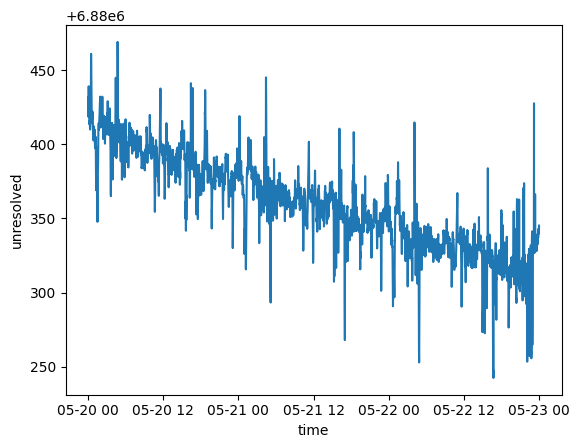

In [34]:
sns.lineplot(df[(df.index>'2024-05-20')&(df.index<'2024-05-23')]['unresolved'])

<Axes: xlabel='time', ylabel='a [m]'>

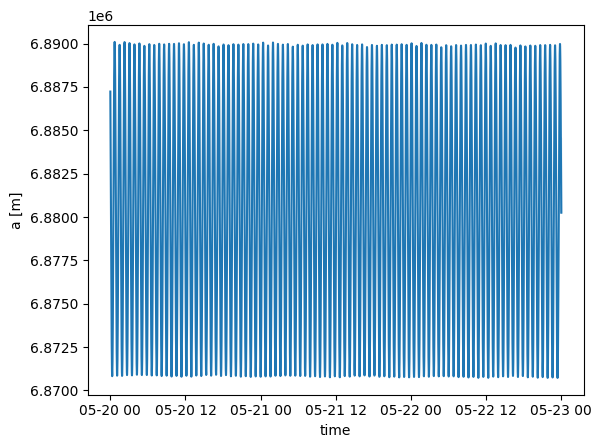

In [33]:
sns.lineplot(df[(df.index>'2024-05-20')&(df.index<'2024-05-23')]['a [m]'])

In [15]:
df.loc[df['res_std'] == 0, 'res_std'] = None

<Axes: ylabel='res_std'>

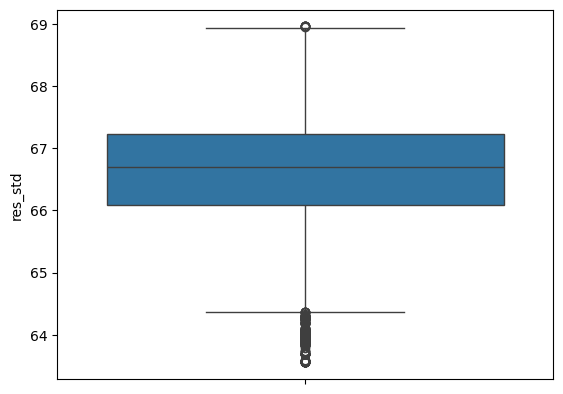

In [16]:
dfc = df[(df.index >= '2024-05-01') & (df.index < '2024-05-15')].copy()
sns.boxplot(dfc['res_std'])

In [17]:
dfc['orbital_decay'].mean(), dfc['orbital_decay'].median(), dfc['orbital_decay'].std()

(53.380975712062884, 45.18393716755366, 33.04859849644419)

In [18]:
dfc['res'].mean(), dfc['res'].median(), dfc['res'].std()

(0.0526776669986984, -1.5672241342253983, 66.5258414386105)

In [19]:
def filter_by_log_intervals(values):
    first_in_interval = {}
    
    for value in values:
        log_interval = int(np.floor(np.log10(value)))
        
        if log_interval not in first_in_interval:
            first_in_interval[log_interval] = value
    
    return list(first_in_interval.values())

Period of the two most prominent frequencies in the a [m]: [47 50] minutes


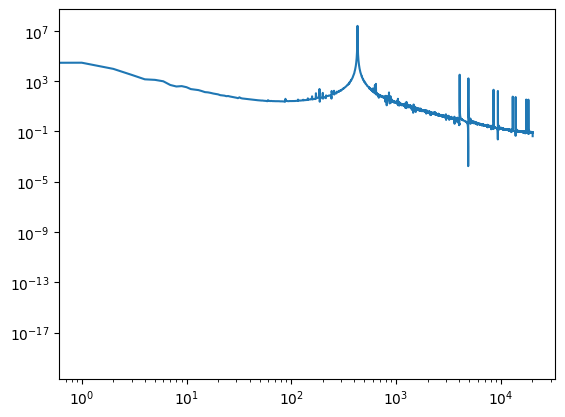

In [20]:
fs = (dfc.index.max() - dfc.index.min()) // pd.Timedelta("30s")
freqencies, spectrum = periodogram(
    dfc['a [m]'],
    fs=fs,
    window="boxcar",
    scaling='spectrum'
)

sorted_spectra_idx = np.argsort(spectrum)[::-1]
sorted_freqs = freqencies[sorted_spectra_idx]
sorted_freqs = sorted_freqs[sorted_freqs > 10]
periods = [round (fs / freq) for freq in sorted_freqs]
periods = list(dict.fromkeys(periods))
periods = np.array(filter_by_log_intervals(periods)[:2])

print(f"Period of the two most prominent frequencies in the a [m]: {periods // 2} minutes")

sns.lineplot(x=freqencies, y=spectrum)
plt.yscale('log')
plt.xscale('log')

Period of the two most prominent frequencies in the orbital_decay: [1680  117] minutes


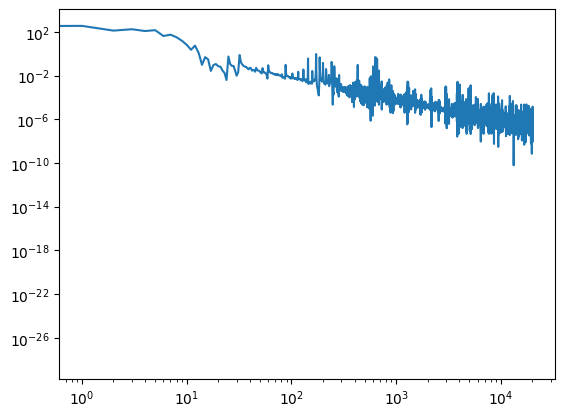

In [21]:
fs = (dfc.index.max() - dfc.index.min()) // pd.Timedelta("30s")
freqencies, spectrum = periodogram(
    dfc['orbital_decay'],
    fs=fs,
    window="boxcar",
    scaling='spectrum'
)

sorted_spectra_idx = np.argsort(spectrum)[::-1]
sorted_freqs = freqencies[sorted_spectra_idx]
sorted_freqs = sorted_freqs[sorted_freqs > 10]
periods = [round (fs / freq) for freq in sorted_freqs]
periods = list(dict.fromkeys(periods))
periods = np.array(filter_by_log_intervals(periods)[:2])

print(f"Period of the two most prominent frequencies in the orbital_decay: {periods // 2} minutes")

sns.lineplot(x=freqencies, y=spectrum)
plt.yscale('log')
plt.xscale('log')

1680 which is 28 hours coincides with 14 periods, the spectrum amplitude is quite low though. Other is orbital period, some low amplitude artefact still remaining after decomposing.

Period of the two most prominent frequencies in the residuals: [31  4] minutes


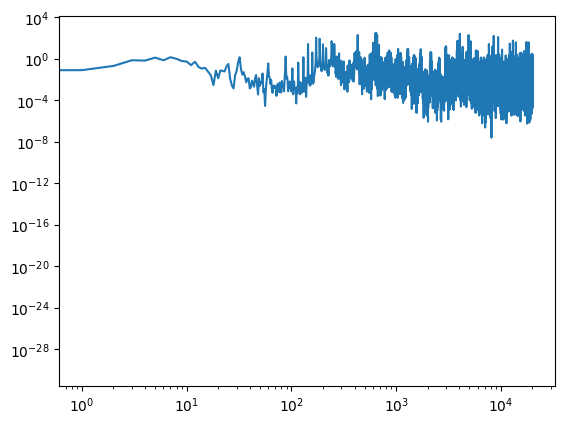

In [22]:
fs = (dfc.index.max() - dfc.index.min()) // pd.Timedelta("30s")
freqencies, spectrum = periodogram(
    dfc['res'],
    fs=fs,
    window="boxcar",
    scaling='spectrum'
)

sorted_spectra_idx = np.argsort(spectrum)[::-1]
sorted_freqs = freqencies[sorted_spectra_idx]
sorted_freqs = sorted_freqs[sorted_freqs > 0]
periods = [round (fs / freq) for freq in sorted_freqs]
periods = list(dict.fromkeys(periods))
periods = np.array(filter_by_log_intervals(periods)[:2])

print(f"Period of the two most prominent frequencies in the residuals: {periods // 2} minutes")

sns.lineplot(x=freqencies, y=spectrum)
plt.yscale('log') 
plt.xscale('log')